# A/B test: retry strategy for declined card transactions

**Question.** When a payment is declined, does a *reason-aware backoff* retry policy recover more
revenue than the current *immediate retry* policy?

| | Arm A: control, **immediate retry** | Arm B: treatment, **smart backoff** |
|---|---|---|
| Soft declines (`insufficient_funds`, `do_not_honor`, `processor_unavailable`) | up to 3 retries within seconds | up to 3 retries, spaced out (`processor_unavailable`: 30s/2m/10m; others: 1h/24h/72h) |
| Hard declines (`suspected_fraud`, `expired_card`, `invalid_cvv`) | up to 3 retries anyway | not retried |

**Design (fixed before looking at outcomes)**
* Unit: a declined transaction from `analytics.stg_transactions` (deduplicated, so a re-delivered event can't land in both arms).
* Assignment: deterministic 50/50 split on `md5(transaction_id)`. Stable, reproducible, and independent of every transaction attribute.
* Primary metric: **recovery rate** = share of declined transactions approved by a later retry.
* Test: two-sided two-proportion z-test, α = 0.05. Also reported: absolute and relative lift, 95% CI.
* Guardrails: sample-ratio mismatch (SRM) check and an A/A split to confirm the test machinery is calibrated.

**What's simulated and what's real.** The declined transactions are real rows from the pipeline. Retry
*outcomes* are simulated from per-reason success probabilities (§3), because nothing here is talking to an
issuer. So the p-value is a real test on this sample, but the effect size comes from the outcome model, not
from the world. Use this notebook as the analysis harness, then swap in observed retry outcomes.

In [1]:
import hashlib, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / "warehouse").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from warehouse.client import WAREHOUSE, query

ALPHA = 0.05
A_COLOR, B_COLOR = "#2a78d6", "#eb6834"   # categorical slots 1 and 2
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.axisbelow": True})

## 1. Pre-registered sample size

Fixed **before** looking at outcomes, so the p-value means what it says. Re-running the test as data
streams in and stopping at the first p < 0.05 ("peeking") inflates the false-positive rate well past 5%.
Instead we commit to an n, analyze the **first** `2 × N_PER_ARM` declines *in arrival order*, and call any
run with less data *interim / inconclusive*. Arrival order (`ingested_at`, then Kafka partition/offset) is used
rather than event time because raw is append-only: once a decline has arrived, the cohort never changes, while
a late event could still slip into an event-time cohort and displace a unit. It's also how a live experiment
enrolls units, at the moment they're seen.

In [2]:
BASELINE = 0.30        # assumed control recovery rate (planning assumption)
MDE = 0.07             # smallest absolute lift worth acting on
POWER = 0.80
N_PER_ARM = int(np.ceil(NormalIndPower().solve_power(
    effect_size=proportion_effectsize(BASELINE + MDE, BASELINE), alpha=ALPHA, power=POWER, ratio=1.0)))
N_TOTAL = 2 * N_PER_ARM
print(f"plan: detect {BASELINE:.0%} -> {BASELINE + MDE:.0%} with {POWER:.0%} power at alpha={ALPHA}: "
      f"n = {N_PER_ARM:,} per arm, {N_TOTAL:,} declines total")

plan: detect 30% -> 37% with 80% power at alpha=0.05: n = 712 per arm, 1,424 declines total


## 2. Load declined transactions from the warehouse

In [3]:
available = query("""
    select transaction_id, event_ts, ingested_at, amount, merchant_category, card_type,
           decline_reason, retry_count
    from {schema}.stg_transactions
    where status = 'declined'
    order by ingested_at, kafka_partition, kafka_offset
""")
COMPLETE = len(available) >= N_TOTAL
declines = available.head(N_TOTAL).copy()   # fixed horizon: first N_TOTAL declines to arrive, never more
print(f"{len(available):,} declines available; analyzing {len(declines):,} of the planned {N_TOTAL:,} "
      f"-> {'COMPLETE' if COMPLETE else 'INTERIM: result is not final'}")
declines["amount"] = declines["amount"].astype(float)
declines["retry_count"] = declines["retry_count"].astype(int)
print(f"warehouse={WAREHOUSE}  declined transactions={len(declines):,}  "
      f"event time {declines.event_ts.min()} -> {declines.event_ts.max()}")
declines.decline_reason.value_counts().rename("n").to_frame()

1,979 declines available; analyzing 1,424 of the planned 1,424 -> COMPLETE
warehouse=postgres  declined transactions=1,424  event time 2026-10-06 23:44:05.935000 -> 2026-10-07 00:29:42.638000


,n
decline_reason,
processor_unavailable,525
insufficient_funds,389
do_not_honor,234
suspected_fraud,126
invalid_cvv,76
expired_card,74


## 3. Outcome model (the simulated part)

Per-attempt probability that a retry is approved, by decline reason and strategy. Immediate retries mostly hit
the same condition that caused the decline (no new funds, outage still on). Spacing retries out gives the
condition time to clear. Every previous client-side retry (`retry_count`) cuts the odds by 15%.

Outcomes are drawn from a per-transaction RNG seeded by `(transaction_id, arm)`, so a transaction's
outcome never changes as more data arrives and the whole analysis is reproducible.

In [4]:
P_SUCCESS = pd.DataFrame({
    #                         immediate  backoff
    "insufficient_funds":    (0.040,     0.090),
    "do_not_honor":          (0.050,     0.070),
    "processor_unavailable": (0.350,     0.500),
    "suspected_fraud":       (0.010,     0.000),   # B does not retry hard declines
    "expired_card":          (0.000,     0.000),
    "invalid_cvv":           (0.020,     0.000),
}, index=["A", "B"]).T
MAX_RETRIES = 3
PRIOR_RETRY_PENALTY = 0.85

def h(s: str) -> int:
    return int(hashlib.md5(s.encode()).hexdigest(), 16)

def simulate(row, arm: str) -> tuple[bool, int]:
    """Return (recovered, attempts_used) for one declined transaction under a strategy."""
    p = P_SUCCESS.at[row.decline_reason, arm] * PRIOR_RETRY_PENALTY ** row.retry_count
    if p == 0:
        return False, 0
    rng = np.random.default_rng(h(f"{row.transaction_id}|{arm}") % 2**32)
    for attempt in range(1, MAX_RETRIES + 1):
        if rng.random() < p:
            return True, attempt
    return False, MAX_RETRIES

P_SUCCESS

,A,B
insufficient_funds,0.04,0.09
do_not_honor,0.05,0.07
processor_unavailable,0.35,0.50
suspected_fraud,0.01,0.00
expired_card,0.00,0.00
invalid_cvv,0.02,0.00


## 4. Randomize and run the experiment

In [5]:
declines["arm"] = np.where(declines.transaction_id.map(h) % 2 == 0, "A", "B")
sim = declines.apply(lambda r: simulate(r, r.arm), axis=1, result_type="expand")
declines["recovered"], declines["attempts"] = sim[0].astype(bool), sim[1].astype(int)

# Guardrail 1: sample-ratio mismatch. Did the 50/50 split come out ~50/50?
counts = declines.arm.value_counts().reindex(["A", "B"])
srm_p = stats.chisquare(counts).pvalue
print(f"arm sizes A={counts.A:,} B={counts.B:,}  SRM chi-square p={srm_p:.3f} "
      f"({'OK' if srm_p > 0.001 else 'SAMPLE RATIO MISMATCH: stop and investigate'})")

# Balance check: arms should look alike on pre-treatment attributes.
balance = declines.groupby("arm").agg(n=("transaction_id", "size"), avg_amount=("amount", "mean"),
                                      avg_prior_retries=("retry_count", "mean"))
balance.join(pd.crosstab(declines.arm, declines.decline_reason, normalize="index").round(3))

arm sizes A=717 B=707  SRM chi-square p=0.791 (OK)


,n,avg_amount,avg_prior_retries,do_not_honor,expired_card,insufficient_funds,invalid_cvv,processor_unavailable,suspected_fraud
arm,,,,,,,,,
A,717,143.455607,0.702929,0.155,0.056,0.272,0.060,0.371,0.086
B,707,140.817893,0.736917,0.174,0.048,0.274,0.047,0.366,0.091


## 5. Primary result: two-proportion z-test

In [6]:
summary = declines.groupby("arm").agg(n=("recovered", "size"), recovered=("recovered", "sum"),
                                      retries_sent=("attempts", "sum"),
                                      recovered_amount=("amount", lambda s: s[declines.loc[s.index, "recovered"]].sum()))
summary["recovery_rate"] = summary.recovered / summary.n
n_a, n_b = summary.n.A, summary.n.B
x_a, x_b = summary.recovered.A, summary.recovered.B
p_a, p_b = x_a / n_a, x_b / n_b

# Two-sided z-test with pooled variance under H0: p_A == p_B.
z_stat, p_value = proportions_ztest([x_b, x_a], [n_b, n_a], alternative="two-sided")

# Same test by hand, as a check on the library call.
p_pool = (x_a + x_b) / (n_a + n_b)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
z_manual = (p_b - p_a) / se_pool
p_manual = 2 * stats.norm.sf(abs(z_manual))
assert np.isclose(z_stat, z_manual) and np.isclose(p_value, p_manual)

# Effect size with a 95% CI (Newcombe score interval for the difference: better coverage than Wald).
ci_lo, ci_hi = confint_proportions_2indep(x_b, n_b, x_a, n_a, method="newcomb", compare="diff", alpha=ALPHA)
abs_lift = p_b - p_a
rel_lift = abs_lift / p_a
rel_lo, rel_hi = ci_lo / p_a, ci_hi / p_a   # approximate: treats p_A as fixed

result = pd.Series({
    "recovery rate A (immediate)": f"{p_a:.2%}  ({x_a:,}/{n_a:,})",
    "recovery rate B (backoff)":   f"{p_b:.2%}  ({x_b:,}/{n_b:,})",
    "absolute lift (B - A)":       f"{abs_lift * 100:+.2f} pts  [95% CI {ci_lo * 100:+.2f}, {ci_hi * 100:+.2f}]",
    "relative lift":               f"{rel_lift:+.1%}  [~{rel_lo:+.1%}, {rel_hi:+.1%}]",
    "z":                           f"{z_stat:.3f}",
    "p-value (two-sided)":         f"{p_value:.2e}" if p_value < 1e-3 else f"{p_value:.4f}",
    "retries sent A / B":          f"{summary.retries_sent.A:,} / {summary.retries_sent.B:,}",
    "recovered $ A / B":           f"${summary.recovered_amount.A:,.0f} / ${summary.recovered_amount.B:,.0f}",
}, name="result")
result.to_frame()

,result
recovery rate A (immediate),28.87% (207/717)
recovery rate B (backoff),38.19% (270/707)
absolute lift (B - A),"+9.32 pts [95% CI +4.42, +14.16]"
relative lift,"+32.3% [~+15.3%, +49.1%]"
z,3.725
p-value (two-sided),1.95e-04
retries sent A / B,"1,793 / 1,381"
recovered $ A / B,"$24,072 / $38,481"


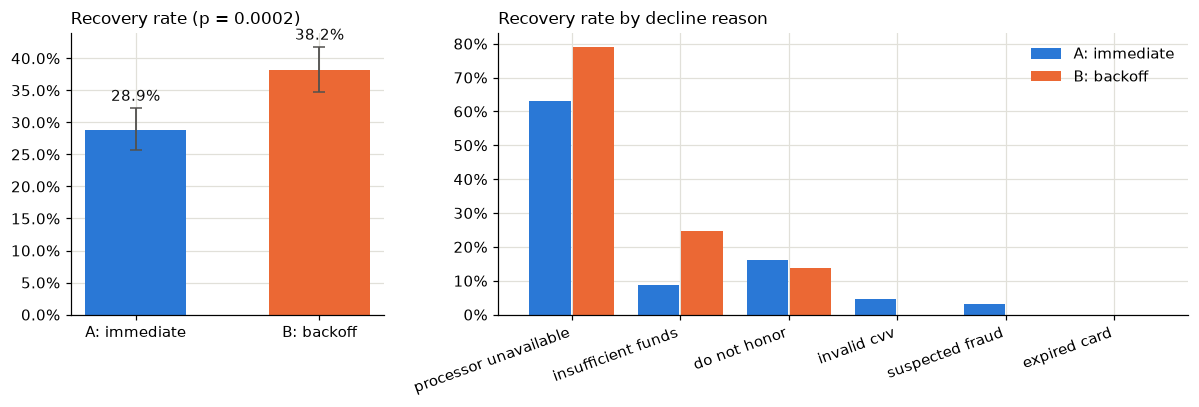

size       sum        mean       
arm                      A    B    A    B      A      B
decline_reason                                         
do_not_honor           111  123   18   17  0.162  0.138
expired_card            40   34    0    0  0.000  0.000
insufficient_funds     195  194   17   48  0.087  0.247
invalid_cvv             43   33    2    0  0.047  0.000
processor_unavailable  266  259  168  205  0.632  0.792
suspected_fraud         62   64    2    0  0.032  0.000

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 2.2]})

# Left: recovery rate per arm with 95% Wilson intervals.
ax = axes[0]
for i, (arm, color, label) in enumerate([("A", A_COLOR, "A: immediate"), ("B", B_COLOR, "B: backoff")]):
    lo, hi = stats.binomtest(int(summary.recovered[arm]), int(summary.n[arm])).proportion_ci(method="wilson")
    rate = summary.recovery_rate[arm]
    ax.bar(i, rate, color=color, width=0.55)
    ax.errorbar(i, rate, yerr=[[rate - lo], [hi - rate]], color="#52514e", capsize=4, lw=1.2)
    ax.text(i, hi + 0.005, f"{rate:.1%}", ha="center", va="bottom", color="#0b0b0b")
ax.set_xticks([0, 1], ["A: immediate", "B: backoff"])
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title(f"Recovery rate (p = {p_value:.2g})", loc="left", fontsize=11)

# Right: by decline reason (descriptive only; no per-reason significance claims).
ax = axes[1]
by_reason = declines.pivot_table(index="decline_reason", columns="arm", values="recovered", aggfunc="mean")
by_reason = by_reason.loc[by_reason.max(axis=1).sort_values(ascending=False).index]
x = np.arange(len(by_reason))
ax.bar(x - 0.2, by_reason.A, width=0.38, color=A_COLOR, label="A: immediate")
ax.bar(x + 0.2, by_reason.B, width=0.38, color=B_COLOR, label="B: backoff")
ax.set_xticks(x, [r.replace("_", " ") for r in by_reason.index], rotation=20, ha="right")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title("Recovery rate by decline reason", loc="left", fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

declines.groupby(["decline_reason", "arm"]).recovered.agg(["size", "sum", "mean"]).unstack("arm").round(3)

## 6. Is the test machinery calibrated? (A/A checks)

If the assignment and the z-test are sound, splitting **one** arm in half by an independent hash should show
no effect, and across many random A/A splits about 5% should come out "significant" at α = 0.05.

In [8]:
ctrl = declines[declines.arm == "A"]
half = ctrl.transaction_id.map(lambda t: h("aa-salt|" + t)) % 2 == 0
aa_z, aa_p = proportions_ztest([ctrl.recovered[half].sum(), ctrl.recovered[~half].sum()],
                               [half.sum(), (~half).sum()])
print(f"single A/A split: {ctrl.recovered[half].mean():.2%} vs {ctrl.recovered[~half].mean():.2%}, p={aa_p:.3f}")

rng = np.random.default_rng(2026)
y = ctrl.recovered.to_numpy()
fp = 0
N_SPLITS = 2000
for _ in range(N_SPLITS):
    m = rng.random(len(y)) < 0.5
    if m.sum() and (~m).sum() and y.sum():
        fp += proportions_ztest([y[m].sum(), y[~m].sum()], [m.sum(), (~m).sum()])[1] < ALPHA
print(f"A/A false-positive rate over {N_SPLITS} random splits: {fp / N_SPLITS:.1%} (expect ~{ALPHA:.0%})")

single A/A split: 29.14% vs 28.57%, p=0.866


A/A false-positive rate over 2000 random splits: 5.1% (expect ~5%)


## 7. Power: could this sample have detected a smaller effect?

In [9]:
power_calc = NormalIndPower()
achieved = power_calc.power(effect_size=proportion_effectsize(p_b, p_a), nobs1=n_a, ratio=n_b / n_a, alpha=ALPHA)
# Smallest absolute lift detectable with 80% power at this sample size (search on Cohen's h).
h_mde = power_calc.solve_power(nobs1=n_a, ratio=n_b / n_a, alpha=ALPHA, power=0.8)
p_mde = np.sin(np.arcsin(np.sqrt(p_a)) + h_mde / 2) ** 2
print(f"power to detect the observed lift: {achieved:.1%}")
print(f"minimum detectable effect at 80% power: {p_a:.2%} -> {p_mde:.2%} ({(p_mde - p_a) * 100:+.2f} pts)")

power to detect the observed lift: 96.2%
minimum detectable effect at 80% power: 28.87% -> 35.81% (+6.94 pts)


## 8. Readout

In [10]:
sig = p_value < ALPHA
calibrated = abs(fp / N_SPLITS - ALPHA) < 0.02
# Which reasons drive the lift: per-reason rate difference weighted by that reason's share of declines.
share = declines.decline_reason.value_counts(normalize=True)
contrib = ((by_reason.B - by_reason.A) * share).sort_values(ascending=False)
drivers = " and ".join(f"`{r}`" for r in contrib.index[:2])
status = ("**Final:** pre-registered sample reached." if COMPLETE else
          f"**INTERIM, NOT A RESULT:** {len(declines):,} of {N_TOTAL:,} planned declines. "
          "Don't act on the p-value below until the sample is complete.")
display(Markdown(f"""
{status}

**Smart backoff (B) recovered {p_b:.1%} of declined transactions vs {p_a:.1%} for immediate retry (A):
{abs_lift * 100:+.2f} pts absolute, {rel_lift:+.0%} relative (95% CI on the difference
{ci_lo * 100:+.2f} to {ci_hi * 100:+.2f} pts). Two-proportion z = {z_stat:.2f}, two-sided p = {p_value:.2g}:
{"statistically significant" if sig else "not statistically significant"} at α = {ALPHA}.**

* n = {n_a:,} (A) / {n_b:,} (B) declined transactions; SRM check p = {srm_p:.2f}; A/A false-positive rate
  {fp / N_SPLITS:.1%} ({"the harness is calibrated" if calibrated else "off from the nominal 5%: check before trusting p"}).
* B sent {summary.retries_sent.B:,} retries vs {summary.retries_sent.A:,} for A
  ({(summary.retries_sent.B / summary.retries_sent.A - 1):+.0%}), because it skips hard declines. Fewer retries
  also means fewer fees and less issuer-side retry-abuse risk.
* Most of the difference comes from {drivers} (rate gap weighted by share of declines).
* Planned for a {MDE * 100:.0f}-pt lift at {POWER:.0%} power; with the observed baseline the minimum
  detectable effect at this n is {(p_mde - p_a) * 100:+.1f} pts.

**Caveat:** outcomes come from the simulation in §3, so this measures the *assumed* effect on a real sample.
Before acting, re-run with observed retry outcomes. Note that B's recoveries arrive hours or days later, which
matters for cash-flow and customer experience.
"""))


**Final:** pre-registered sample reached.

**Smart backoff (B) recovered 38.2% of declined transactions vs 28.9% for immediate retry (A):
+9.32 pts absolute, +32% relative (95% CI on the difference
+4.42 to +14.16 pts). Two-proportion z = 3.73, two-sided p = 0.0002:
statistically significant at α = 0.05.**

* n = 717 (A) / 707 (B) declined transactions; SRM check p = 0.79; A/A false-positive rate
  5.1% (the harness is calibrated).
* B sent 1,381 retries vs 1,793 for A
  (-23%), because it skips hard declines. Fewer retries
  also means fewer fees and less issuer-side retry-abuse risk.
* Most of the difference comes from `processor_unavailable` and `insufficient_funds` (rate gap weighted by share of declines).
* Planned for a 7-pt lift at 80% power; with the observed baseline the minimum
  detectable effect at this n is +6.9 pts.

**Caveat:** outcomes come from the simulation in §3, so this measures the *assumed* effect on a real sample.
Before acting, re-run with observed retry outcomes. Note that B's recoveries arrive hours or days later, which
matters for cash-flow and customer experience.
